# Data Cleaning - VNExpress News Dataset

Dataset được crawl từ hai chuyên mục:

- Sức khỏe
- Giải trí

Notebook này thực hiện:

1. Kiểm tra dữ liệu thô
2. Làm sạch dữ liệu
3. Chuẩn hóa định dạng
4. Tạo feature mới
5. Xuất dataset sạch để phân tích tiếp

## 1. Import thư viện

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

pd.set_option("display.max_columns", None)

## 2. Đọc dữ liệu thô

In [26]:
DATA_PATH = "../data/raw_data/"

df = pd.read_csv(DATA_PATH + "vnexpress_raw_data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1236, 11)


,title,description,date,content,thumbnail,author,tags,group,category,nums_of_comments,url
0,5 gia vị hỗ trợ giảm hình thành cục máu đông,Tỏi chứa allicin có thể hạn chế hình thành cục...,"Thứ tư, 11/3/2026, 08:30 (GMT+7)","Cùng với tim, mạch máu là một phần của hệ tuần...",https://i1-suckhoe.vnecdn.net/2026/03/10/image...,NaN,"cục máu đông, thực phẩm, dinh dưỡng",Sức khỏe,Các bệnh,0,https://vnexpress.net/5-gia-vi-ho-tro-giam-hin...
1,Sắc vóc bạn gái Liên Bỉnh Phát,Ngọc Kayla - cựu thành viên nhóm Mắt Ngọc - có...,"Chủ nhật, 25/1/2026, 19:00 (GMT+7)",Ngọc Kayla sánh đôi bạn trai dự buổi công chiế...,https://i1-giaitri.vnecdn.net/2026/01/24/ngoc-...,NaN,"liên bỉnh phát, ngọc kayla",Giải trí,Thời trang,0,https://vnexpress.net/sac-voc-ban-gai-lien-bin...
2,Midu cùng dàn sao dự thảm đỏ 'Tinh hoa Việt',TP HCMDiễn viên Midu cùng dàn sao Việt chưng d...,"Thứ hai, 26/1/2026, 21:07 (GMT+7)","Midu diện áo dài xuyên thấu, họa tiết hoa 3D d...",https://i1-giaitri.vnecdn.net/2026/01/26/z7470...,NaN,"tp hcm, tinh hoa việt, midu, dàn sao",Giải trí,Giới sao,0,https://vnexpress.net/midu-cung-dan-sao-du-tha...
3,Lý Liên Kiệt: 'Từng rất mệt vì cố giống Hoàng ...,Diễn viên gốc Hoa Lý Liên Kiệt nói trước đây í...,"Thứ hai, 9/3/2026, 16:29 (GMT+7)","TheoCNA, sao võ thuật nói về công việc, đời số...",https://i1-giaitri.vnecdn.net/2026/03/09/ly-li...,NaN,"lý liên kiệt, sao võ thuật, hoàng phi hồng, co...",Giải trí,Giới sao,0,https://vnexpress.net/ly-lien-kiet-tung-rat-me...
4,Italy chi 35 triệu USD mua tranh của Caravaggio,Chính phủ Italy mua bức tranh do Caravaggio vẽ...,"Thứ năm, 12/3/2026, 21:23 (GMT+7)","TheoAP, thông tin được Bộ Văn hóa Italy công b...",https://i2-vnexpress.vnecdn.net/2026/03/12/34x...,NaN,"caravaggio, italy, portrait of monsignor maffe...",Giải trí,Sân khấu - Mỹ thuật,0,https://vnexpress.net/italy-chi-35-trieu-usd-m...


## 3. Thông tin dữ liệu

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             1231 non-null   str    
 1   description       1231 non-null   str    
 2   date              1232 non-null   str    
 3   content           1231 non-null   str    
 4   thumbnail         1235 non-null   str    
 5   author            0 non-null      float64
 6   tags              1231 non-null   str    
 7   group             1222 non-null   str    
 8   category          1222 non-null   str    
 9   nums_of_comments  1236 non-null   int64  
 10  url               1236 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 106.3 KB


## 4. Kiểm tra dữ liệu thiếu

In [28]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df))*100
})

missing_df.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
author,1236,100.000000
group,14,1.132686
category,14,1.132686
title,5,0.404531
description,5,0.404531
content,5,0.404531
tags,5,0.404531
date,4,0.323625
thumbnail,1,0.080906
nums_of_comments,0,0.000000


## 5. Phân bố dữ liệu ban đầu

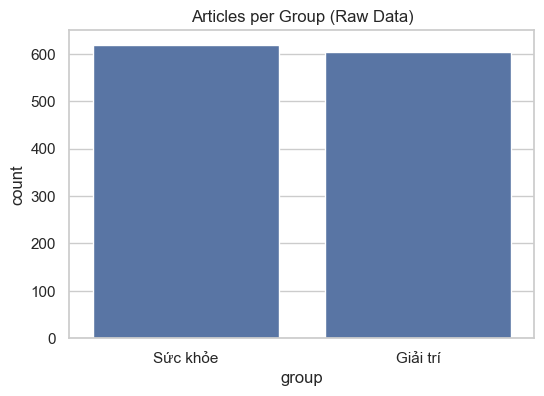

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="group")

plt.title("Articles per Group (Raw Data)")
plt.show()

# 6. Loại bỏ dữ liệu trùng lặp

In [30]:
print("Rows before:", len(df))

df = df.drop_duplicates(subset="url")

print("Rows after:", len(df))

Rows before: 1236
Rows after: 1236


## 7. Loại bỏ bài viết thiếu nội dung

In [31]:
df = df.dropna(subset=["title", "content"])

print("Rows after removing missing:", len(df))

Rows after removing missing: 1231


# 8. Làm sạch dữ liệu văn bản

In [32]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

In [33]:
df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

## 9. Phân tích độ dài văn bản

In [34]:
df["title_length"] = df["title"].apply(lambda x: len(x.split()))
df["content_length"] = df["content"].apply(lambda x: len(x.split()))

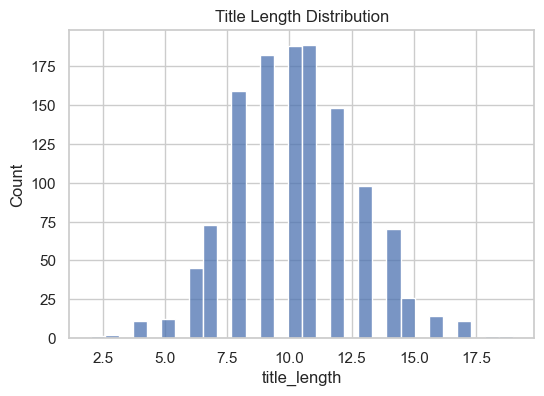

In [35]:
plt.figure(figsize=(6,4))

sns.histplot(df["title_length"], bins=30)

plt.title("Title Length Distribution")

plt.show()

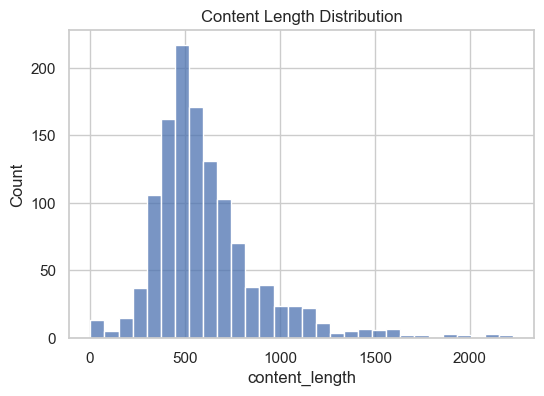

In [36]:
plt.figure(figsize=(6,4))

sns.histplot(df["content_length"], bins=30)

plt.title("Content Length Distribution")

plt.show()

# 10. Chuẩn hóa định dạng ngày

In [37]:
def clean_date(text):

    if pd.isna(text):
        return text

    text = re.sub(r'^Thứ.*?,\s*', '', text)

    text = re.sub(r'\(.*?\)', '', text)

    return text.strip()

In [38]:
df["date"] = df["date"].apply(clean_date)

In [39]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y, %H:%M",
    errors="coerce"
)

## 11. Chuẩn hóa group/category

In [40]:


def normalize_category(row):
    group = row["group"]
    category = row["category"]

    # Trường hợp crawler lấy được: Các bệnh > Hô hấp

    # Nếu muốn làm theo hướng gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    # if group == "Các bệnh":
    #     group = "Sức khỏe"
    #     category = "Các bệnh"

    # Nếu muốn giữ nguyên các nhóm riêng biệt, nhưng vẫn gộp các nhóm liên quan đến sức khỏe vào một nhóm chung, có thể sử dụng đoạn code sau:
    if group == "Các bệnh":
        group = "Sức khỏe"

    return pd.Series([group, category])


df[["group", "category"]] = df.apply(normalize_category, axis=1)

# print("Unique groups:", df["group"].unique())
# print("Unique categories:", df["category"].unique())

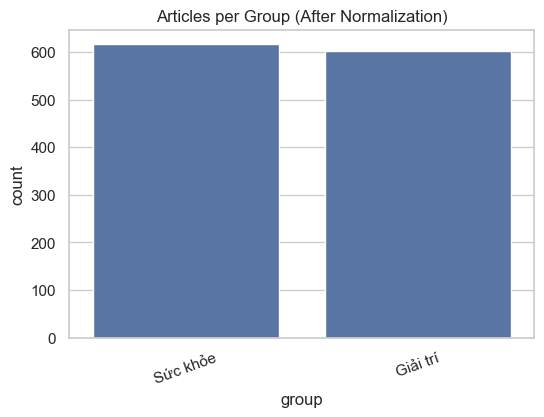

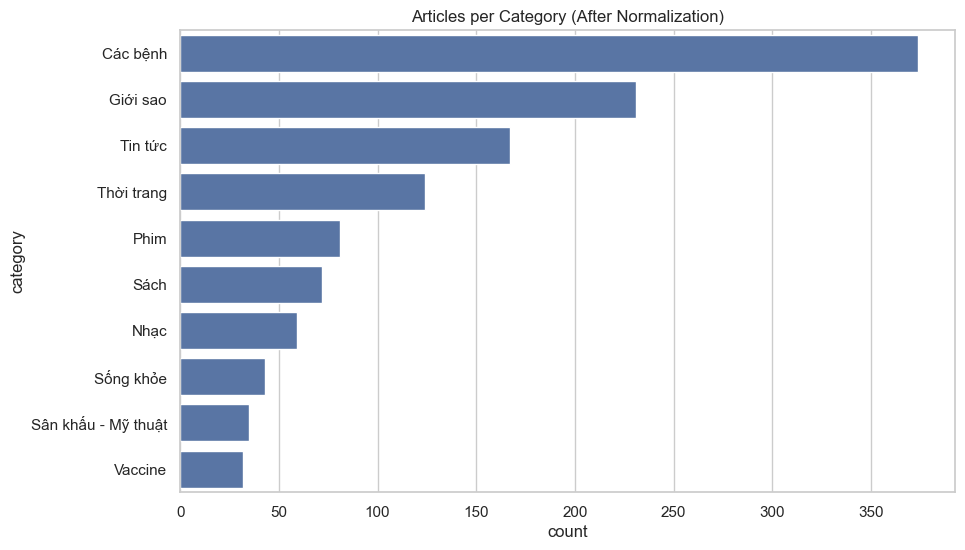

In [41]:
# Visualize group distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="group")
plt.title("Articles per Group (After Normalization)")
plt.xticks(rotation=20)
plt.show()


# Visualize category distribution

plt.figure(figsize=(10,6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Articles per Category (After Normalization)")

plt.show()

## 12. Tạo feature thời gian

In [42]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

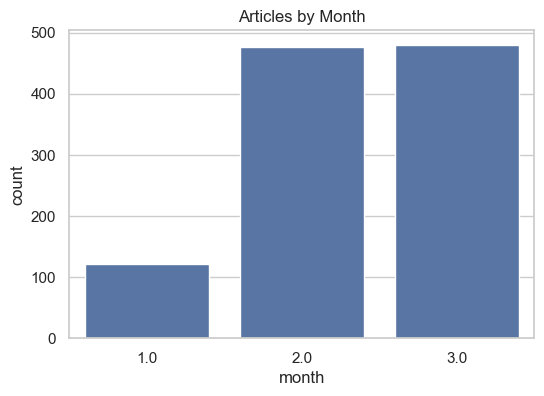

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="month")

plt.title("Articles by Month")

plt.show()

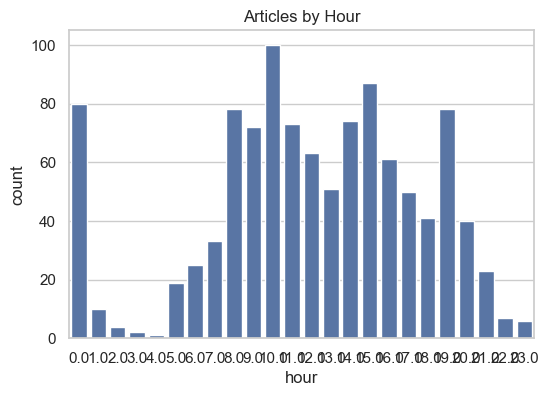

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="hour")

plt.title("Articles by Hour")

plt.show()

## 13. Phân tích số lượng bình luận

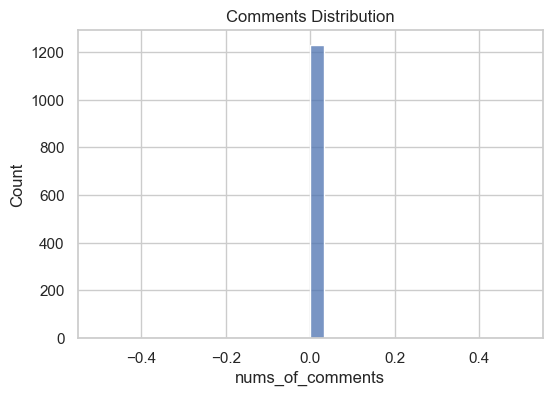

In [45]:
plt.figure(figsize=(6,4))

sns.histplot(df["nums_of_comments"], bins=30)

plt.title("Comments Distribution")

plt.show()

## 14. Kiểm tra dataset sau khi clean

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 1231 entries, 0 to 1235
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             1231 non-null   str           
 1   description       1231 non-null   str           
 2   date              1078 non-null   datetime64[us]
 3   content           1231 non-null   str           
 4   thumbnail         1231 non-null   str           
 5   author            0 non-null      float64       
 6   tags              1226 non-null   str           
 7   group             1218 non-null   object        
 8   category          1218 non-null   object        
 9   nums_of_comments  1231 non-null   int64         
 10  url               1231 non-null   str           
 11  title_length      1231 non-null   int64         
 12  content_length    1231 non-null   int64         
 13  year              1078 non-null   float64       
 14  month             1078 non-null   float6

In [47]:
df.describe()

,date,author,nums_of_comments,title_length,content_length,year,month,hour
count,1078,0.0,1231.0,1231.000000,1231.000000,1078.0,1078.000000,1078.000000
mean,2026-02-24 06:00:08.794063,NaN,0.0,10.259951,611.649878,2026.0,2.332096,12.022263
min,2026-01-22 08:37:00,NaN,0.0,2.000000,2.000000,2026.0,1.000000,0.000000
25%,2026-02-16 18:00:00,NaN,0.0,9.000000,434.500000,2026.0,2.000000,9.000000
50%,2026-02-27 14:02:00,NaN,0.0,10.000000,545.000000,2026.0,2.000000,12.000000
75%,2026-03-06 16:45:00,NaN,0.0,12.000000,716.500000,2026.0,3.000000,16.000000
max,2026-03-13 18:00:00,NaN,0.0,19.000000,2228.000000,2026.0,3.000000,23.000000
std,NaN,NaN,0.0,2.484229,294.556528,0.0,0.669753,5.525619


## 15. Lưu dataset đã clean

In [48]:
df.to_csv("../data/vnexpress_clean_data.csv", index=False)

print("Saved clean dataset")

Saved clean dataset
